# BTSP in an open field with a corridor (2-comp)

In [1]:
import copy
import importlib
from pathlib import Path
import time
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons, value_neurons
from predhpc.util import gen_util, ext_util, learn_util, params_util, plot_util, animate_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "openfield_corridor"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Initialise parameters

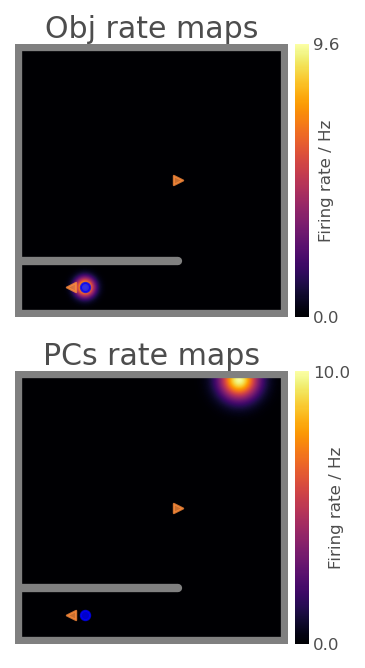

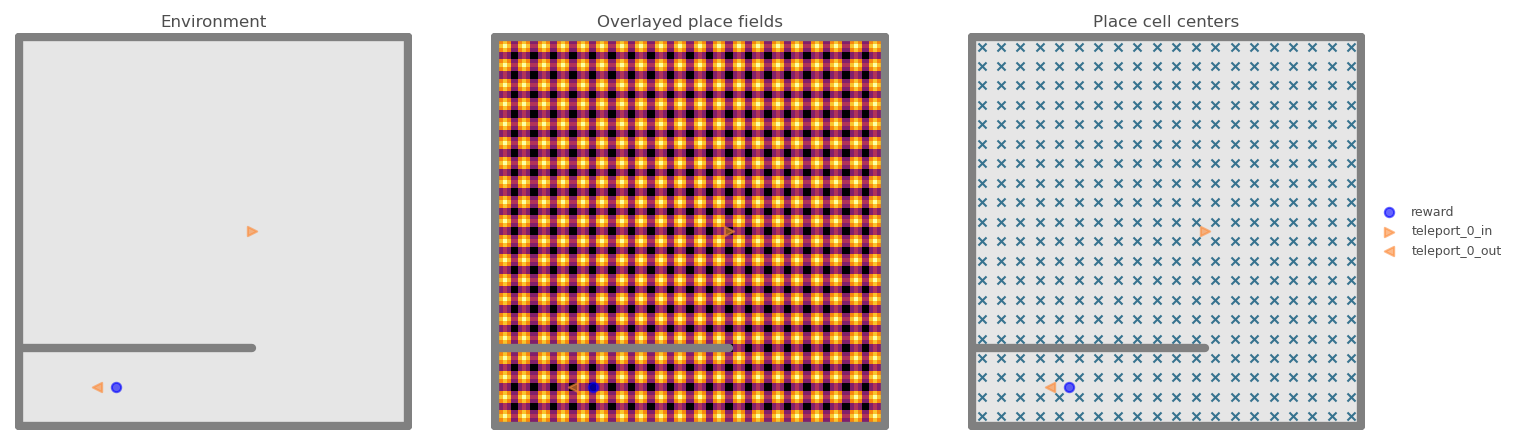

In [5]:
RECORD_WEIGHTS_FREQ = 1000
MAX_NUM_STEPS = 15000
USE_HEBBIAN = False

Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="openfield_corridor",
    log_BTSP=True,
)

Pyrs, fields_axes, aggreg_ax1D = run_manager.init_env_objects(
    Pyr_params=Pyr_params,
    environment="openfield_corridor", 
    plot=True
)

Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)
updater = run_manager.VNUpdater(Ag)

ALL_FIGURES["fields"] = fields_axes
ALL_FIGURES["fields_aggreg"] = aggreg_ax1D

Target is reward: False.


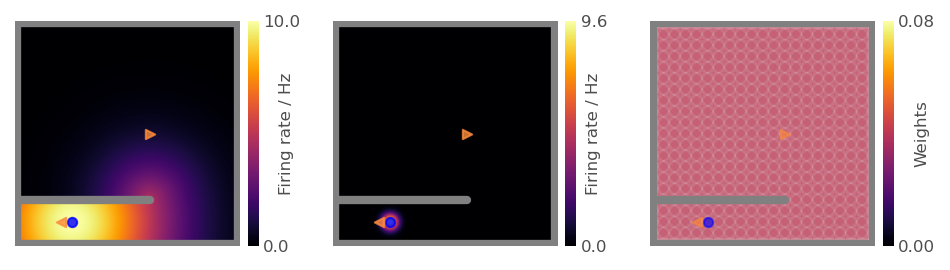

In [6]:
target_is_reward = (Ag.target_df.loc[len(Ag.target_df) - 1, "object_type_name"] == "reward")
print(f"Target is reward: {target_is_reward}.")

Pyrs.set_learn(False)
Pyrs.set_BTSP_learn(False)

_, ax1D = plt.subplots(1, 3, figsize=(6, 1.5))
updater.VN.plot_rate_map(no_legend=True, ax=ax1D[0])
Objs.plot_rate_map(no_legend=True, ax=ax1D[1])
plot_fcts.plot_2D_PFs(
    Pyrs.SomaticCompartment, alpha=0.3, s=120, mark_BTSP=False, no_legend=True, ax=ax1D[2]
)

ALL_FIGURES["field_summary"] = ax1D

## 1. Learn

In [7]:
Ag.allow_teleportation(False)

In [9]:
learner = run_manager.learn_openfield_BTSP(
    Pyrs,
    use_Hebbian=USE_HEBBIAN,
    max_num_steps=MAX_NUM_STEPS,
    updater=updater,
    teleportation_enabled=True,
)

 10%|███▌                                 | 1447/15000 [00:04<00:36, 373.77it/s]

BTSP event recorded at step 1373 (41.19 sec).


 14%|█████▏                               | 2127/15000 [00:05<00:30, 417.50it/s]

BTSP update applied at step 2067 (62.01 sec).


100%|████████████████████████████████████| 15000/15000 [00:42<00:00, 352.03it/s]

Reached target 19 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from steps 0 to 14999): occurred at step 1373.


In [10]:
Pyrs.SomaticCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.SomaticCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
No neuron had at least two BTSP events triggered.


In [11]:
Ag.log_teleportation()
Ag.trajectory_df

No teleportation events.


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.139231,0.135274,0,0.0,0.771213,0.548734,2000.0,60.0,2000.0,60.0
1,1.781474,1.862171,2000,60.0,0.280848,0.548734,4000.0,120.0,2000.0,60.0
2,1.357407,1.082753,4000,120.0,1.783609,0.548734,6000.0,180.0,2000.0,60.0
3,0.378070,1.233519,6000,180.0,1.392495,0.548734,8000.0,240.0,2000.0,60.0
4,0.751886,1.866580,8000,240.0,1.325421,0.548734,10000.0,300.0,2000.0,60.0
5,1.296334,1.340785,10000,300.0,0.813130,0.548734,12000.0,360.0,2000.0,60.0
6,1.865118,1.334523,12000,360.0,1.002274,0.548734,14000.0,420.0,2000.0,60.0
7,0.469584,0.510996,14000,420.0,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
Ag.target_df.head()

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,reward,0.0,0.5,0.2,0,0.00,"[[0, 300], [300, 600], [600, 900], [900, 1200]]",1365.0,40.95,1200.0,36.0,1365.0,40.95
1,0.0,reward,0.0,0.5,0.2,1365,40.95,[],1366.0,40.98,0.0,0.0,1.0,0.03
2,0.0,reward,0.0,0.5,0.2,1366,40.98,[],1367.0,41.01,0.0,0.0,1.0,0.03
3,NaN,no_target,NaN,NaN,NaN,1367,41.01,"[[1367, 1667]]",NaN,NaN,300.0,9.0,300.0,9.00
4,NaN,no_target,NaN,NaN,NaN,1667,50.01,"[[1667, 1967]]",NaN,NaN,300.0,9.0,300.0,9.00


Linear speed mean: 22.74 cm/s, std: 13.48 cm/s.


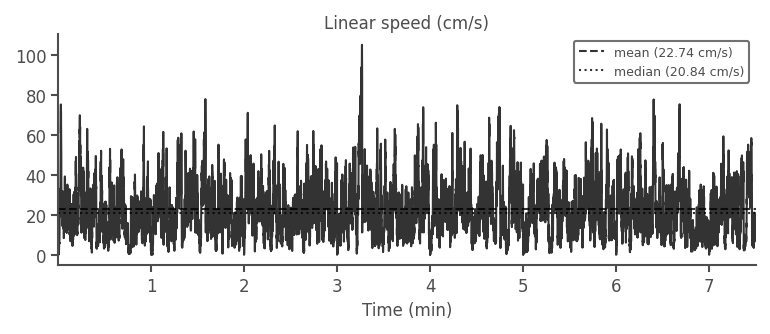

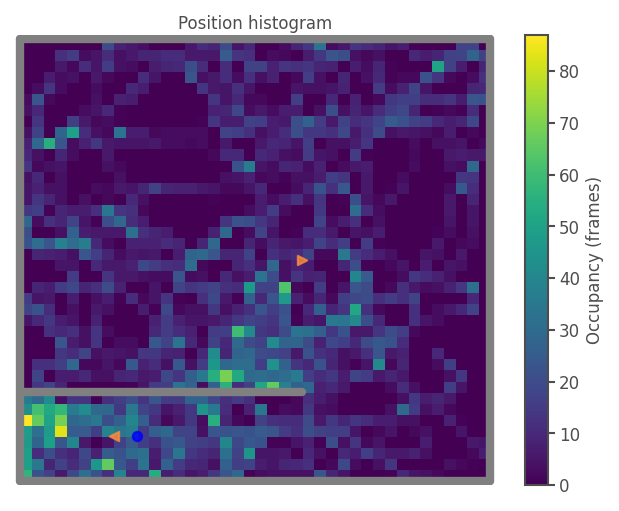

In [13]:
Ag.log_speed_stats()
sub_ax_speed = Ag.plot_speed(mark_mean=True, mark_median=True)
sub_ax_occ = Ag.plot_occupancy(no_legend=True)

ALL_FIGURES["1-initial_speed"] = sub_ax_speed
ALL_FIGURES["1-initial_occupancy"] = sub_ax_occ

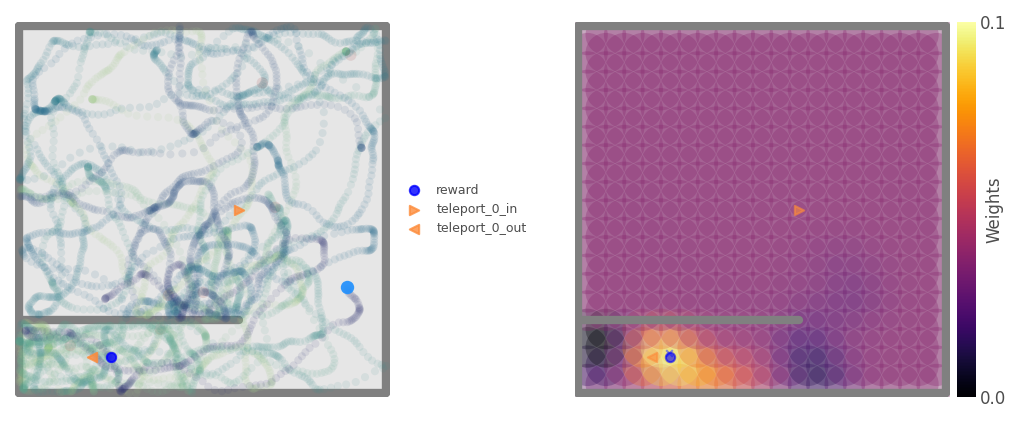

In [14]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.SomaticCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["1-initial_spatial"] = ax1D

/home/cgillon/homedir/predhpc/predhpc/util/learn_util.py:817: UserWarning: Assessment will assume geodesic wall geometry even though place cell wall geometry is line_of_sight.
  warnings.warn(


Update 1 regul.: 0.8723 (w)


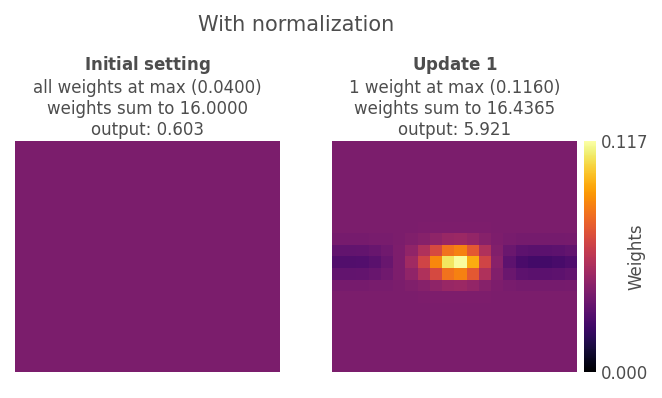

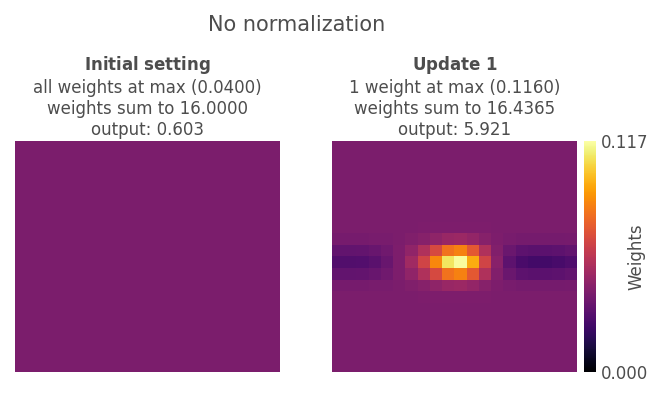

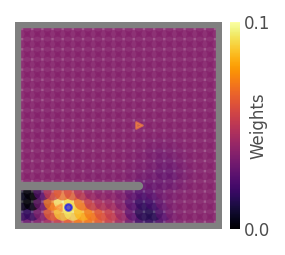

In [16]:
norm_theor_axes, no_norm_theor_axes, act_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    learner.Pyrs.SomaticCompartment,
    output_fr=4.2, # tuned to match actual weights
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_actual_weights"] = act_sub_ax

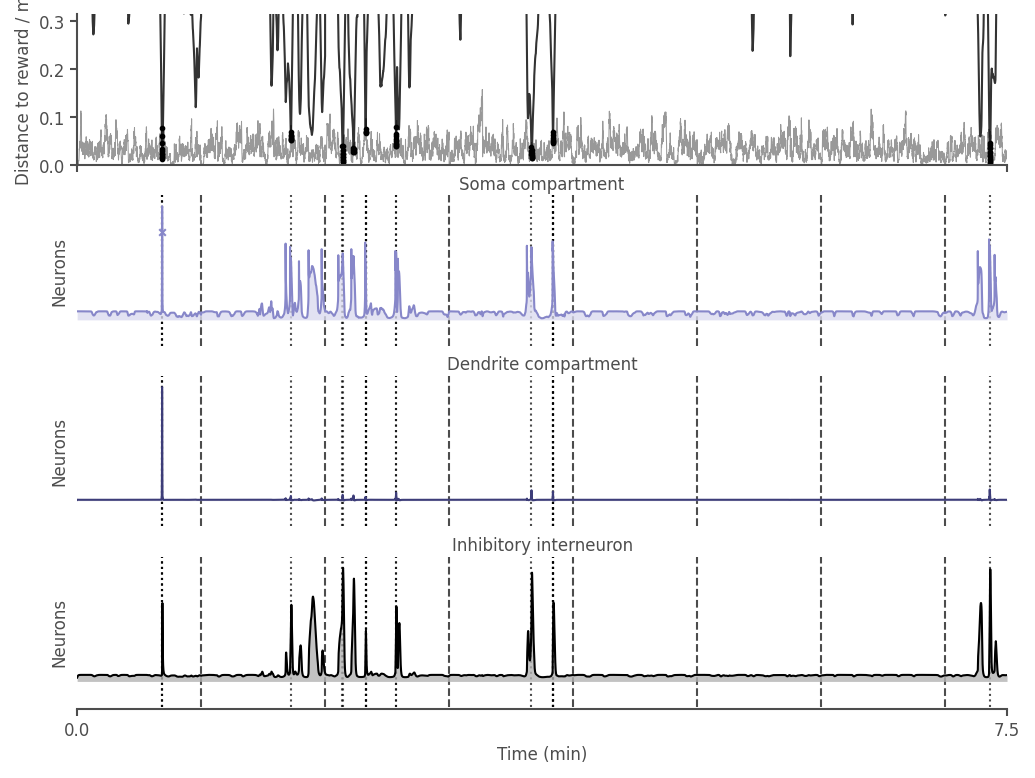

In [17]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(4, 1, figsize=[8, 6], sharex=True)
Ag.plot_distance_to(
    position_name="reward", 
    position=copy.deepcopy(locations["reward"]), 
    mark_below_tolerance=True, 
    tol_prop_to_speed_dt=tol_prop_to_speed_dt,
    zoom_prop=2,
    sub_ax=ax1D[0]
    )
ax1D[0].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[1:])

ALL_FIGURES["1-initial_distance_to_target_single"] = ax1D

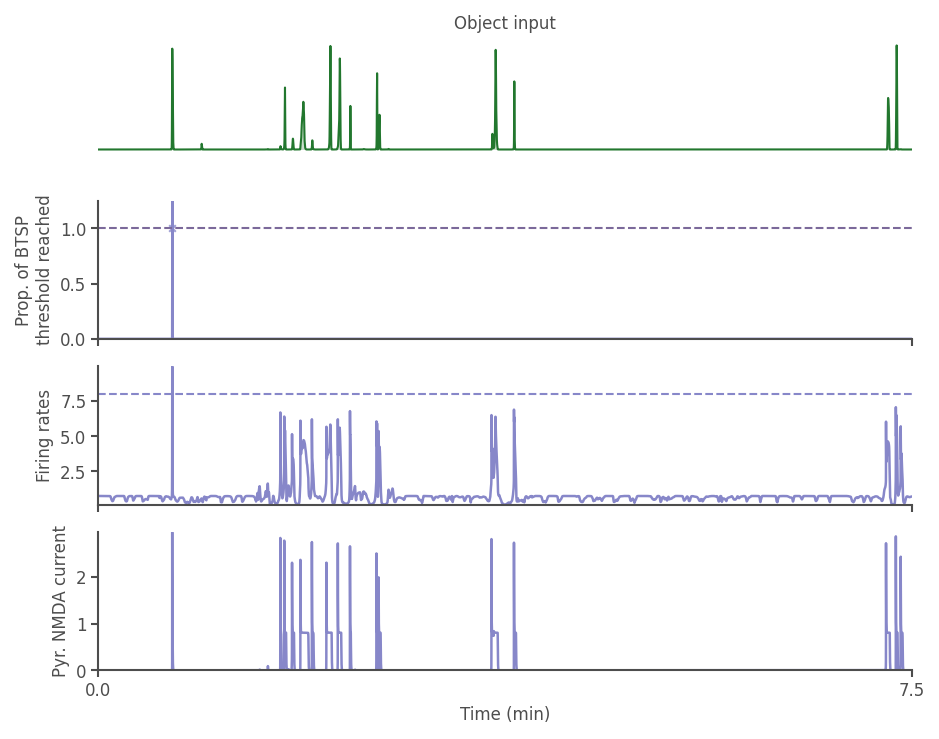

In [18]:
fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)

Objs.plot_rate_timeseries(sub_ax=ax1D[0])
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

Pyrs.SomaticCompartment.plot_BTSP_ramp_factors(axes=ax1D[1:])

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

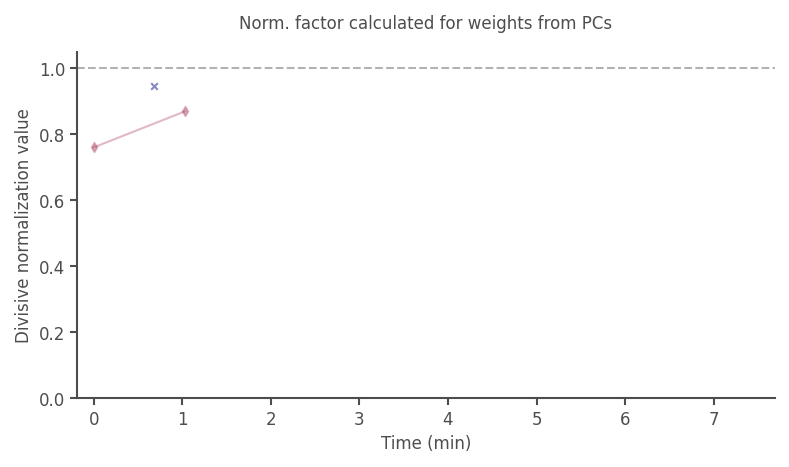

In [19]:
if Pyrs.SomaticCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.SomaticCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norm_time"] = sub_ax

## 2. Enable teleportation

In [20]:
initial_end_time = Ag.t
Ag.allow_teleportation(True)
Ag.set_reward_factor(1)

In [21]:
Ag.get_target_probability_df()

,object_df_idx,object_type_num,object_type_name,idx_within_type,position_x,position_y,teleport_pair_num,teleport_direction,target_factor,target_probability
0,0.0,0.0,reward,0.0,0.5,0.2,NaN,NaN,1,0.333333
1,1.0,1.0,teleport_0_in,0.0,1.2,1.0,0.0,in,1,0.333333
2,NaN,NaN,no_target,NaN,NaN,NaN,NaN,NaN,1,0.333333


In [22]:
learner_with_teleport = Pyrs

num_BTSP = len(Pyrs.SomaticCompartment.history["BTSP_events"])
while len(Ag.teleportation_df) == 0 or len(Pyrs.SomaticCompartment.history["BTSP_events"]) <= num_BTSP:
    if len(Ag.teleportation_df) == 0:
        teleport_start_time = Ag.t
    
    learner_with_teleport = run_manager.learn_openfield_BTSP(
        Pyrs_or_learner=learner_with_teleport,
        use_Hebbian=USE_HEBBIAN,
        max_num_steps=6000,
        updater=updater,
    )

teleport_idx = len(Ag.teleportation_df) - 1

100%|██████████████████████████████████████| 6000/6000 [00:14<00:00, 411.98it/s]


Reached target 1 times.
Trajectory lengths (11) to date: 57.27 +/- 8.62 sec each
Trajectory lengths (11) to date: 1909.09 +/- 287.48 steps each
0 BTSP events triggered (allowed from steps 15000 to 20999).


 24%|█████████                             | 1425/6000 [00:04<00:10, 440.20it/s]

Teleported through pair 0 at step 22351 (670.56 sec.)


 34%|████████████▊                         | 2019/6000 [00:05<00:08, 446.05it/s]

...

Teleported through pair 0 at step 25659 (769.80 sec.)
BTSP event recorded at step 25664 (769.92 sec).


 90%|██████████████████████████████████▏   | 5405/6000 [00:13<00:01, 431.25it/s]

BTSP update applied at step 26358 (790.74 sec).


100%|██████████████████████████████████████| 6000/6000 [00:15<00:00, 386.54it/s]

Reached target 5 times.
Trajectory lengths (14) to date: 57.86 +/- 7.73 sec each
Trajectory lengths (14) to date: 1928.57 +/- 257.54 steps each
1 BTSP event triggered (allowed from steps 15000 to 26999): occurred at step 25664.


In [23]:
additional_steps = 3000

if additional_steps > 0:
    run_manager.run_learner(
        learner_with_teleport,
        updater=updater,
        max_num_steps=additional_steps,
    )

100%|██████████████████████████████████████| 3000/3000 [00:08<00:00, 347.16it/s]

Reached target 9 times.
Trajectory lengths (15) to date: 60.00 +/- 0.00 sec each
Trajectory lengths (15) to date: 2000.00 +/- 0.00 steps each
1 BTSP event triggered (allowed from steps 15000 to 29999): occurred at step 25664.


In [24]:
print(f"{int(Pyrs.SomaticCompartment.get_BTSP_counts()[0])} BTSP events recorded in total.")

2 BTSP events recorded in total.


In [25]:
Ag.log_teleportation()
Ag.trajectory_df

Teleportation events:
    through pair 0 at step 22351 (670.56 sec.)
    through pair 0 at step 22938 (688.17 sec.)
    through pair 0 at step 25659 (769.80 sec.)


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.139231,0.135274,0,0.0,0.771213,0.303383,2000.0,60.0,2000.0,60.0
1,1.781474,1.862171,2000,60.0,0.280848,0.303383,4000.0,120.0,2000.0,60.0
2,1.357407,1.082753,4000,120.0,1.783609,0.303383,6000.0,180.0,2000.0,60.0
3,0.378070,1.233519,6000,180.0,1.392495,0.303383,8000.0,240.0,2000.0,60.0
4,0.751886,1.866580,8000,240.0,1.325421,0.303383,10000.0,300.0,2000.0,60.0
5,1.296334,1.340785,10000,300.0,0.813130,0.303383,12000.0,360.0,2000.0,60.0
6,1.865118,1.334523,12000,360.0,1.002274,0.303383,14000.0,420.0,2000.0,60.0
7,0.469584,0.510996,14000,420.0,1.090428,0.303383,16000.0,480.0,2000.0,60.0
8,0.367334,1.447446,16000,480.0,1.357412,0.303383,18000.0,540.0,2000.0,60.0
9,0.448067,0.557548,18000,540.0,1.605254,0.303383,20000.0,600.0,2000.0,60.0


In [26]:
Ag.teleportation_df

,teleport_pair_num,step_num,time,in_object_idx,in_object_type_num,in_object_type_name,in_position_x,in_position_y,in_vector_x,in_vector_y,...,in_velocity_y,out_object_idx,out_object_type_num,out_object_type_name,out_position_x,out_position_y,out_vector_x,out_vector_y,out_velocity_x,out_velocity_y
0,0,22351,670.53,1,1,teleport_0_in,1.058630,0.945292,-0.141370,-0.054708,...,-0.297021,2,2,teleport_0_out,0.541370,0.254708,0.141370,0.054708,0.439028,-0.297021
1,0,22938,688.14,1,1,teleport_0_in,1.151094,0.965017,-0.048906,-0.034983,...,0.115672,2,2,teleport_0_out,0.448906,0.234983,0.048906,0.034983,0.207075,0.115672
2,0,25659,769.77,1,1,teleport_0_in,1.100658,0.956155,-0.099342,-0.043845,...,-0.151294,2,2,teleport_0_out,0.499342,0.243845,0.099342,0.043845,0.387627,-0.151294


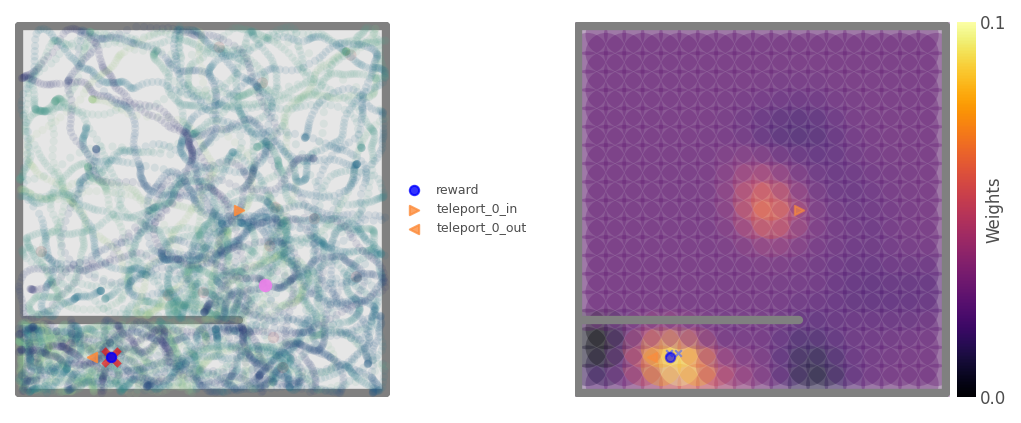

In [28]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.SomaticCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["2-with_teleport_spatial"] = ax1D

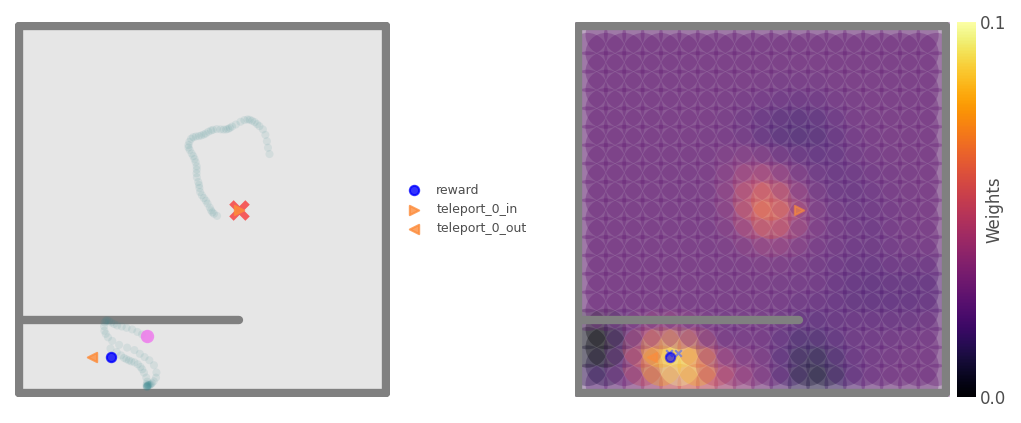

In [31]:
# visualize weights after a specific BTSP event
event_idx = 0 # from when teleport was allowed

last_teleport_time = Ag.teleportation_df.loc[teleport_idx, "time"]
recorded_weights_with_teleport = learner_with_teleport.get_recorded_weights()

teleport_weights = recorded_weights_with_teleport["weights"]
teleport_weight_time = recorded_weights_with_teleport["time"]
if len(teleport_weights) > event_idx + 1:
    fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
    Ag.plot_trajectories(alpha=0.1, ax=ax1D[0], t_start=last_teleport_time - 5, t_end=last_teleport_time + 5)
    
    plot_fcts.plot_2D_PFs(
        Pyrs.SomaticCompartment, 
        PFs=teleport_weights[event_idx + 1], 
        t_end=teleport_weight_time[event_idx + 1],
        alpha=0.3, 
        s=380,
        plot_BTSP_events=True, 
        no_legend=True, 
        ax=ax1D[1]
    )
    
    ALL_FIGURES["2-with_teleport_spatial_first"] = ax1D

In [32]:
Pyrs.SomaticCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.SomaticCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
Shortest interval between applying and subsequently triggering a BTSP event in the same neuron was 23595 steps (707.85 sec.).


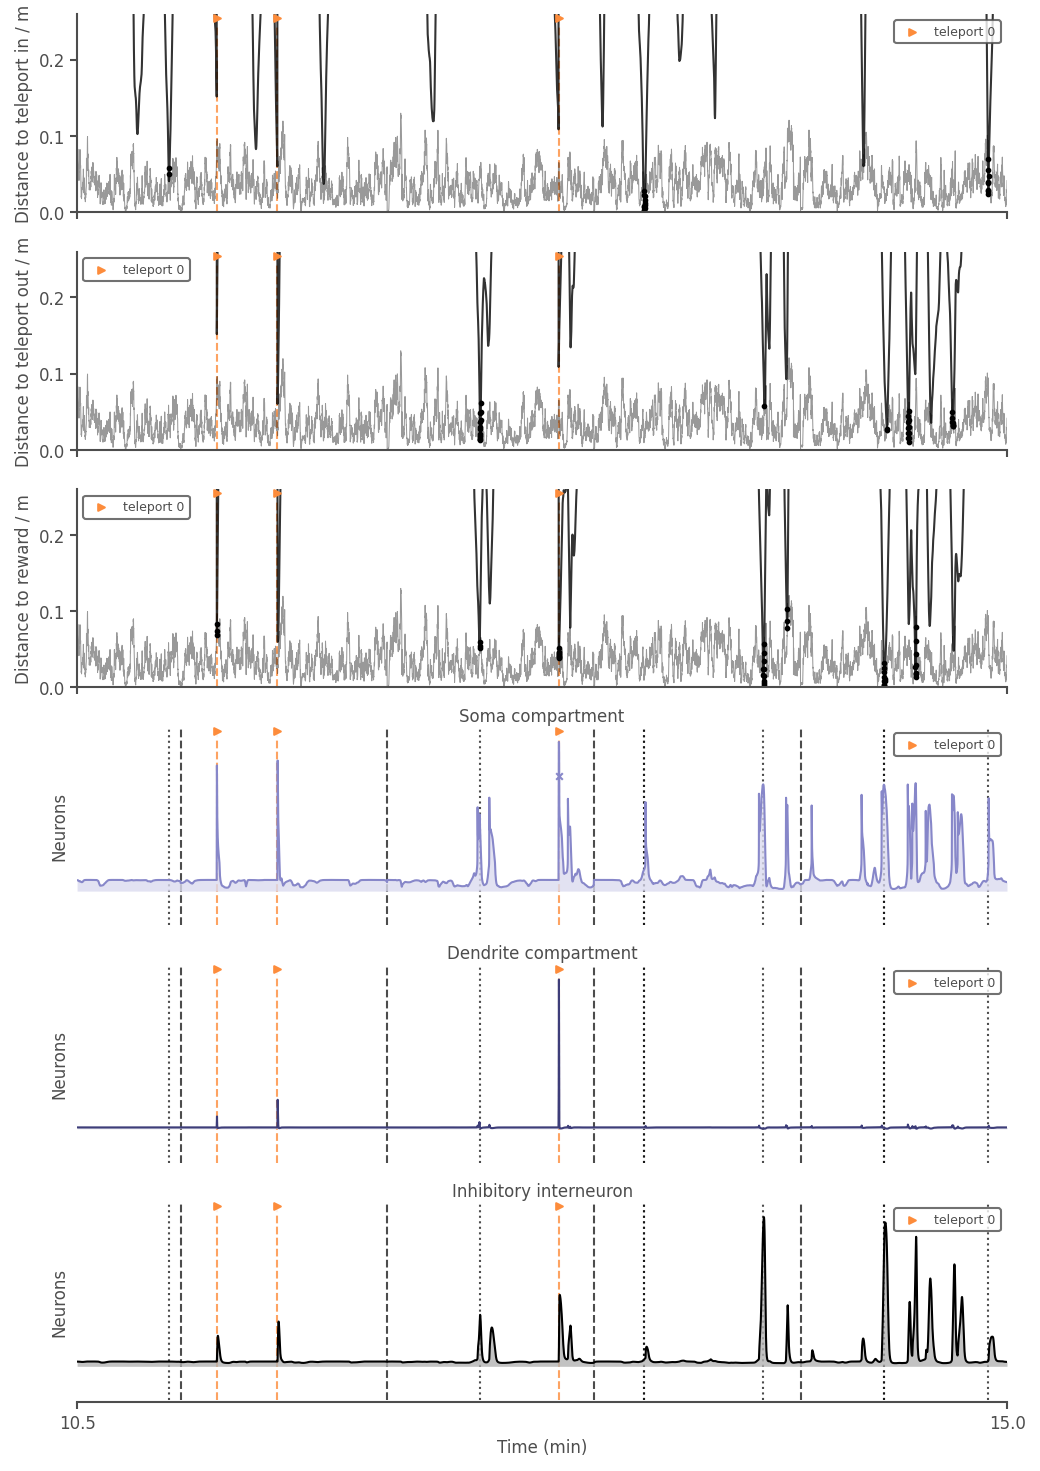

In [34]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

names = ["teleport in", "teleport out", "reward"]
plot_to_locations = list(locations["teleport_in_out"]) + [locations["reward"]]

fig, ax1D = plt.subplots(6, 1, figsize=[8, 12], sharex=True)
for i, (name, plot_to_loc) in enumerate(zip(names, plot_to_locations)):
    Ag.plot_distance_to(
        position_name=name, 
        position=copy.deepcopy(plot_to_loc), 
        sub_ax=ax1D[i],
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        t_start=teleport_start_time,
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[3:], t_start=teleport_start_time)

Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=teleport_start_time, timeseries=True)

ALL_FIGURES["2-with_teleport_distance_to_target_single"] = ax1D

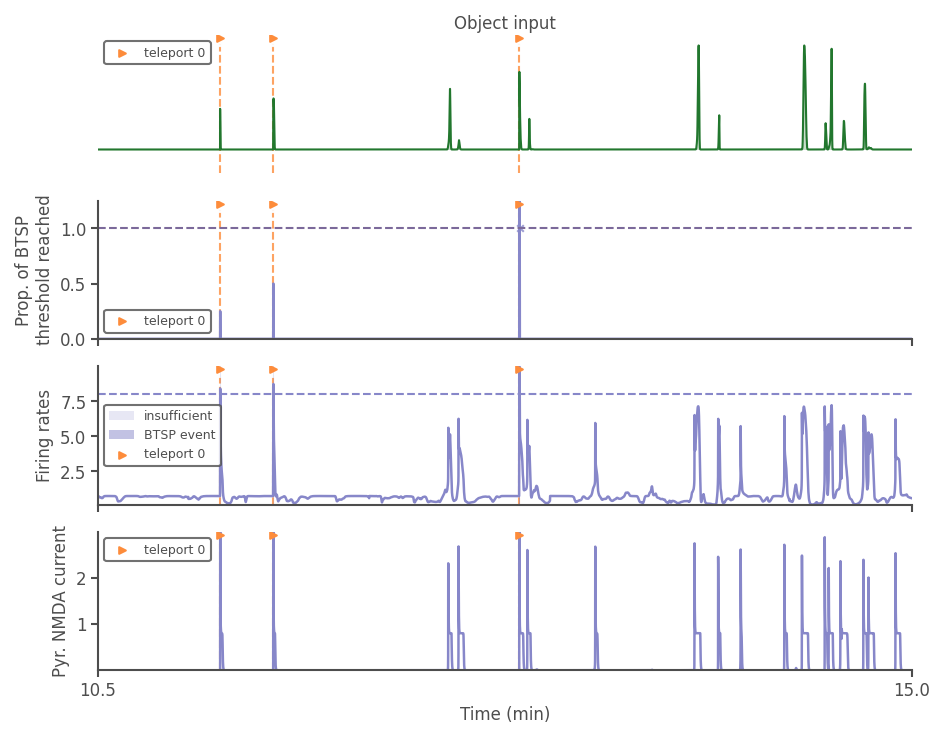

In [35]:
fig, ax1D = plt.subplots(4, 1, figsize=[7, 5.5], sharex=True)

Objs.plot_rate_timeseries(sub_ax=ax1D[0], t_start=teleport_start_time)
ax1D[0].set_title("Object input")
ax1D[0].set_ylabel("")
plot_util.clear_bottom(ax1D[0])

Pyrs.SomaticCompartment.plot_BTSP_ramp_factors(axes=ax1D[1:], t_start=teleport_start_time)
Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=teleport_start_time, timeseries=True)

ALL_FIGURES["2-with_teleport_BTSP_timeseries"] = ax1D

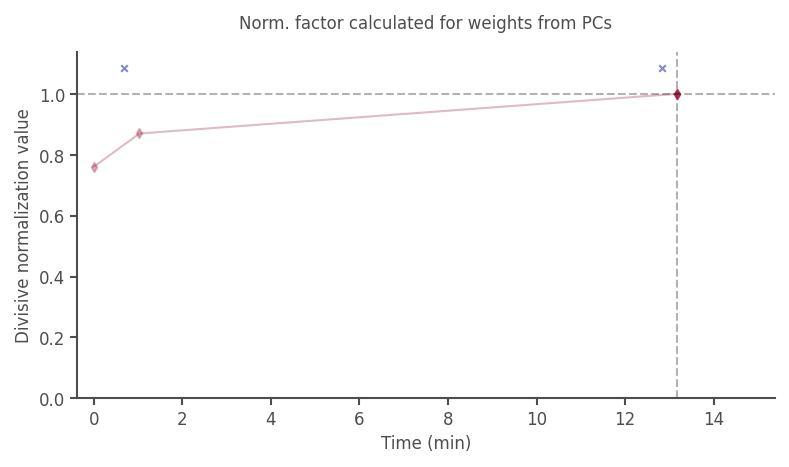

In [36]:
if Pyrs.SomaticCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.SomaticCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["2-with_teleport_weight_norm_time"] = sub_ax

## 3. Additional teleportation event

In [37]:
additional_teleport_start_time = Ag.t

In [38]:
num_teleportations = len(Ag.teleportation_df)
while len(Ag.teleportation_df) < num_teleportations + 2:
    Ag.allow_teleportation(True)
    
    learner_with_teleport = run_manager.learn_openfield_BTSP(
        Pyrs,
        use_Hebbian=USE_HEBBIAN,
        max_num_steps=6000,
        updater=updater
    )

 79%|██████████████████████████████▏       | 4757/6000 [00:13<00:02, 439.40it/s]

Teleported through pair 0 at step 34679 (1040.40 sec.)


100%|██████████████████████████████████████| 6000/6000 [00:15<00:00, 379.30it/s]


Reached target 3 times.
Trajectory lengths (18) to date: 60.00 +/- 0.00 sec each
Trajectory lengths (18) to date: 2000.00 +/- 0.00 steps each
0 BTSP events triggered (allowed from steps 30000 to 35999).


100%|██████████████████████████████████████| 6000/6000 [00:14<00:00, 407.08it/s]


...

Teleported through pair 0 at step 43845 (1315.38 sec.)


 81%|██████████████████████████████▊       | 4861/6000 [00:13<00:02, 423.66it/s]

Teleported through pair 0 at step 46811 (1404.36 sec.)


100%|██████████████████████████████████████| 6000/6000 [00:15<00:00, 375.74it/s]

Reached target 3 times.
Trajectory lengths (24) to date: 60.00 +/- 0.00 sec each
Trajectory lengths (24) to date: 2000.00 +/- 0.00 steps each
0 BTSP events triggered (allowed from steps 42000 to 47999).


In [39]:
additional_steps = 3000

if additional_steps > 0:
    run_manager.run_learner(
        learner_with_teleport,
        updater=updater,
        max_num_steps=additional_steps,
    )

100%|██████████████████████████████████████| 3000/3000 [00:07<00:00, 393.12it/s]

Reached target 6 times.
Trajectory lengths (26) to date: 58.85 +/- 5.77 sec each
Trajectory lengths (26) to date: 1961.54 +/- 192.31 steps each
0 BTSP events triggered (allowed from steps 42000 to 50999).


In [40]:
print(f"{int(Pyrs.SomaticCompartment.get_BTSP_counts()[0])} BTSP events recorded in total.")

2 BTSP events recorded in total.


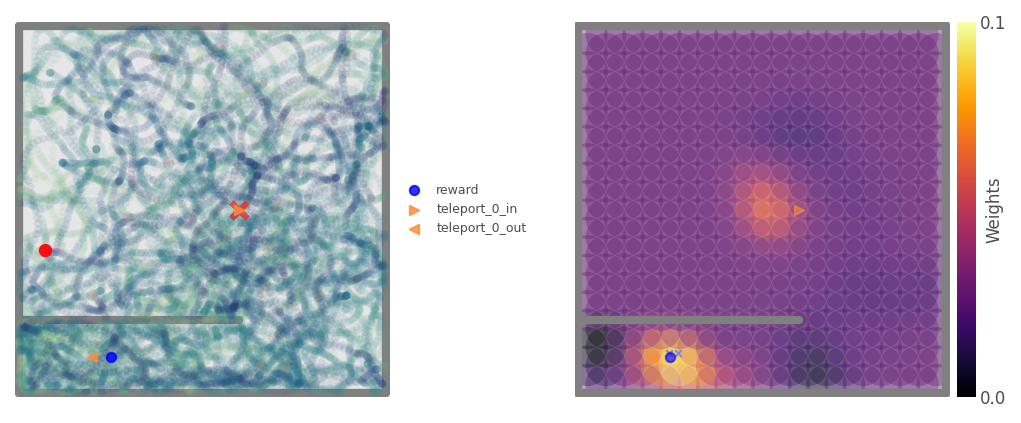

In [41]:
fig, ax1D = plt.subplots(1, 2, figsize=[7, 2.5])
Ag.plot_trajectories(alpha=0.1, ax=ax1D[0])

plot_fcts.plot_2D_PFs(
    Pyrs.SomaticCompartment, alpha=0.3, s=380, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
)

ALL_FIGURES["3-additional_teleport_spatial"] = ax1D

In [42]:
Pyrs.SomaticCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
Pyrs.SomaticCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 696.00 steps (20.88 sec.)
Shortest interval between applying and subsequently triggering a BTSP event in the same neuron was 23595 steps (707.85 sec.).


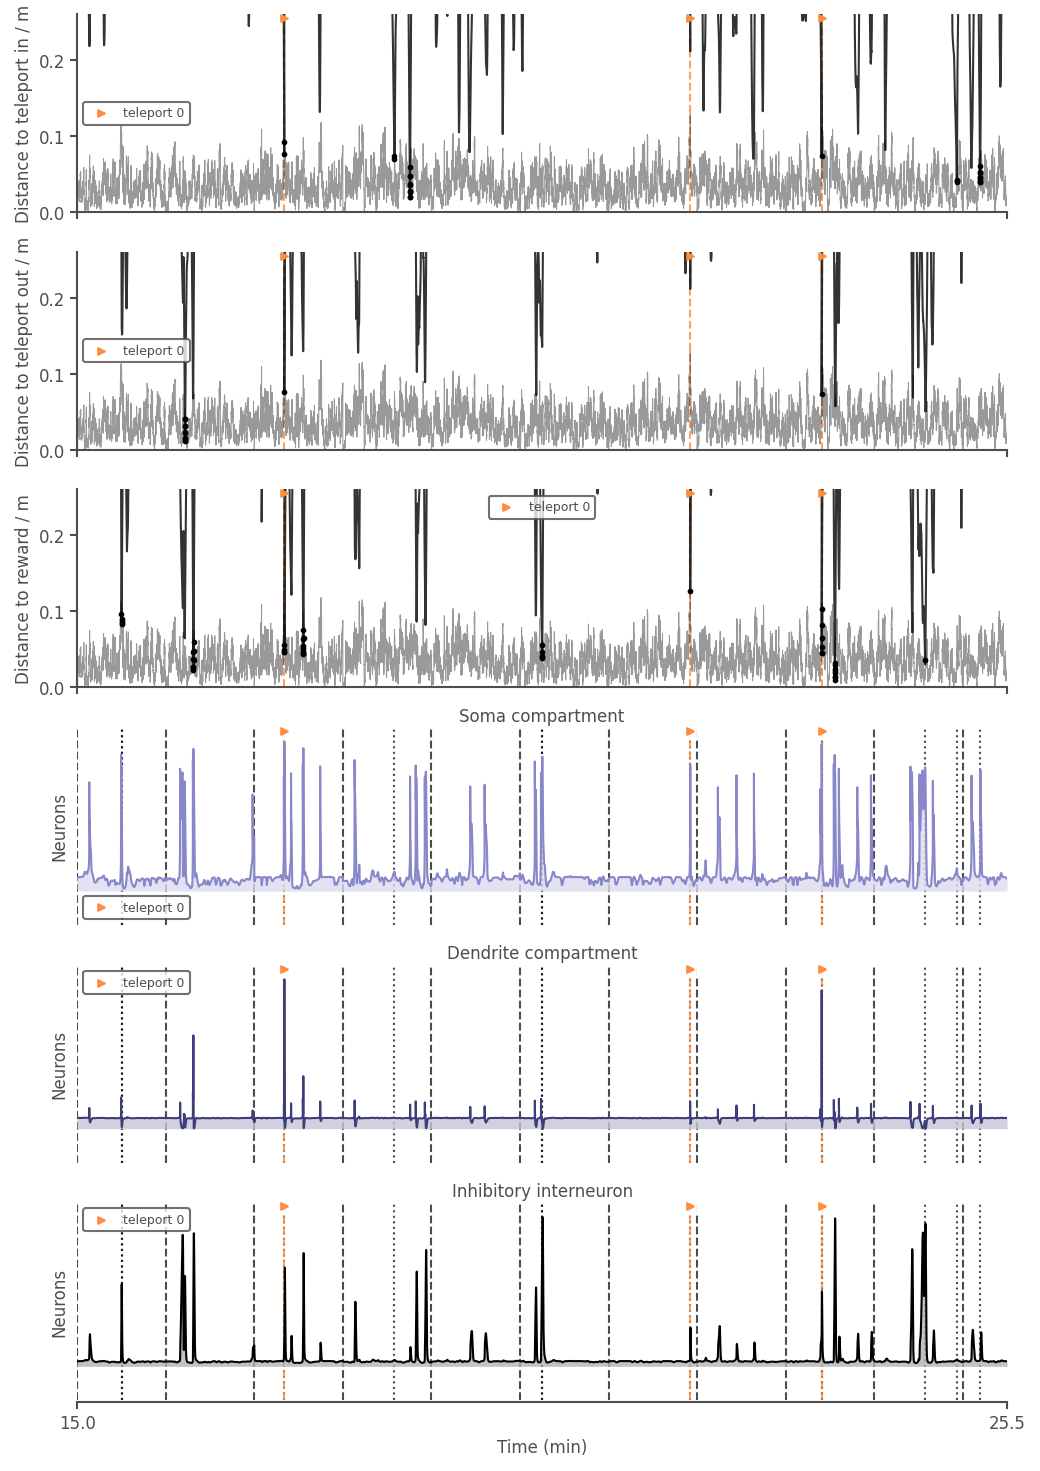

In [48]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

names = ["teleport in", "teleport out", "reward"]
plot_to_locations = list(locations["teleport_in_out"]) + [locations["reward"]]

fig, ax1D = plt.subplots(6, 1, figsize=[8, 12], sharex=True)
for i, (name, plot_to_loc) in enumerate(zip(names, plot_to_locations)):
    Ag.plot_distance_to(
        position_name=name, 
        position=copy.deepcopy(plot_to_loc), 
        sub_ax=ax1D[i],
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        t_start=additional_teleport_start_time,
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[3:], t_start=additional_teleport_start_time)

Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=additional_teleport_start_time, timeseries=True)

ALL_FIGURES["3-additional_teleport_distance_to_target_single"] = ax1D

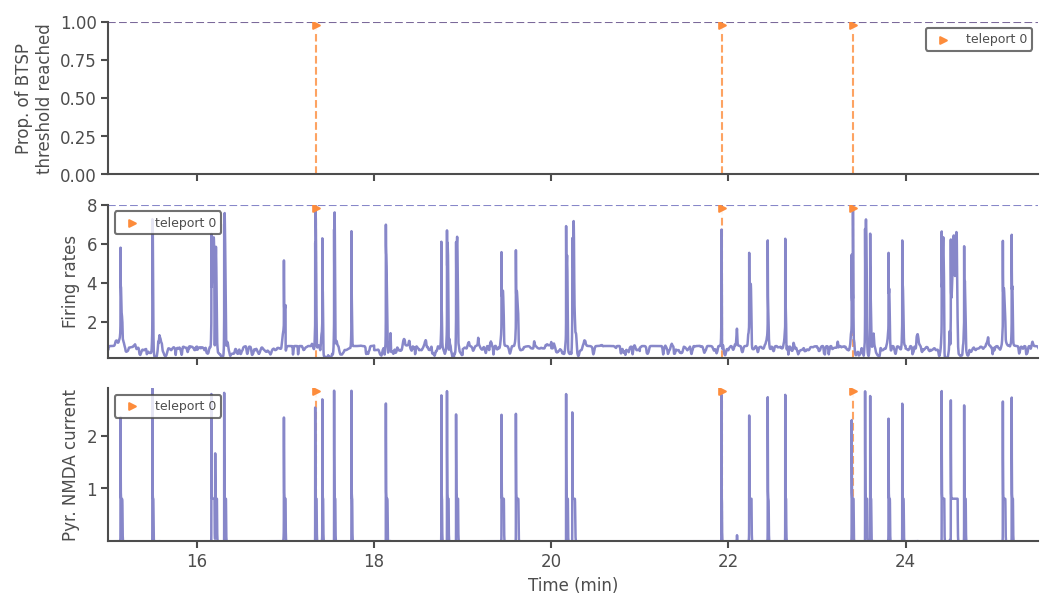

In [50]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.SomaticCompartment.plot_BTSP_ramp_factors(axes=ax1D, t_start=additional_teleport_start_time)
Ag.add_teleportation_markers_to_plots(ax=ax1D, t_start=additional_teleport_start_time, timeseries=True)

ALL_FIGURES["3-additional_teleport_BTSP_timeseries"] = ax1D

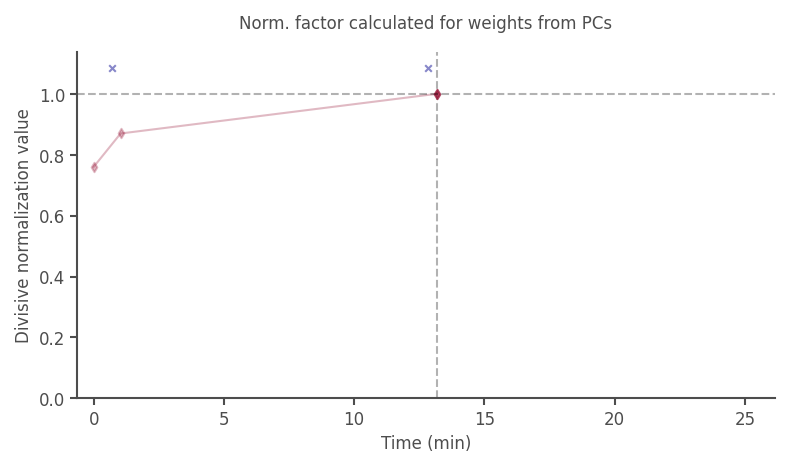

In [51]:
if Pyrs.SomaticCompartment.normalize_weights_divisively:
    sub_ax = Pyrs.SomaticCompartment.plot_normalization_values_over_time(input_layer="PCs")
    ALL_FIGURES["3-additional_teleport_weight_norm_time"] = sub_ax

## 4. Save and animate

### Save figures

In [52]:
SAVE = True

In [53]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 21 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/fields_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/fields_aggreg_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/field_summary_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/1-initial_speed_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/1-initial_occupancy_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/1-initial_spatial_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/BTSP_kernel_norm_1545.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/BTSP_kernel_1545.png  & .svg
Figur

### Animate

In [54]:
ANIMATE = True

In [55]:
if ANIMATE:

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in [learner, learner_with_teleport]]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }

    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["time"],
        "fps": 5,
        "speed_up": 6,
        "s": 400,
        "environment": "openfield",
        "embed_limit": 85.0,
        "autosave": True,
    }

In [56]:
if ANIMATE:
    anim = animate_util.animate(
        t_end=initial_end_time, 
        savename="1-initial_timeseries",
        addendum="teleportation disabled",
        **all_animate_kwargs
    )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/1-initial_timeseries_1546.mp4  & .gif
Animation took 13.15 min. to create.


In [57]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=teleport_start_time,
        savename="2-with_teleport_timeseries",
        addendum="teleportation enabled",
        **all_animate_kwargs
    )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/openfield_corridor/25_05_22/2-with_teleport_timeseries_1559.mp4  & .gif
Animation took 28.61 min. to create.
